# Offline Data Analysis - Piloting

This notebook provides tools for loading and analyzing experimental data from the escape task.

In [1]:
# Import necessary libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Ensure plots appear in notebook
%matplotlib inline

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set figure defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Data Loading Functions

In [2]:
def load_session_data(folder_name, base_path='../data'):
    """
    Load session data from a specified folder.
    Only loads .jsonl, .json, .csv, .tsv, .txt, .npy/.npz, .pkl, .h5 files.
    Image files are skipped.
    """
    if os.path.isabs(folder_name):
        data_path = Path(folder_name)
    else:
        data_path = Path(base_path) / folder_name

    if not data_path.exists():
        print(f"Error: Data folder '{data_path}' does not exist")
        print(f"Attempted path: {data_path.absolute()}")
        return None

    session_data = {
        'folder': folder_name,
        'path': str(data_path),
        'files': {},
        'metadata': {}
    }

    files = list(data_path.iterdir())
    print(f"\nFound {len(files)} items in {folder_name}:")

    for file in files:
        if not file.is_file():
            continue

        # Skip image files entirely
        if file.suffix in ['.png', '.jpg', '.jpeg', '.gif', '.bmp']:
            print(f"  - {file.name} (image, skipped)")
            continue

        print(f"  - {file.name} ({file.stat().st_size / 1024:.1f} KB)")

        if file.suffix == '.json':
            try:
                with open(file, 'r') as f:
                    session_data['files'][file.stem] = json.load(f)
                print(f"    ✓ Loaded JSON")
            except Exception as e:
                print(f"    ✗ Error: {e}")

        elif file.suffix == '.jsonl':
            try:
                data = []
                with open(file, 'r') as f:
                    for line in f:
                        if line.strip():
                            data.append(json.loads(line))
                session_data['files'][file.stem] = pd.DataFrame(data)
                print(f"    ✓ Loaded JSONL as DataFrame ({len(data)} rows)")
            except Exception as e:
                print(f"    ✗ Error: {e}")

        elif file.suffix == '.csv':
            try:
                session_data['files'][file.stem] = pd.read_csv(file)
                print(f"    ✓ Loaded CSV")
            except Exception as e:
                print(f"    ✗ Error: {e}")

        elif file.suffix in ['.tsv', '.txt']:
            try:
                df = pd.read_csv(file, sep='\t')
                if len(df.columns) > 1:
                    # Use stem_tsv to avoid collision with a same-named .jsonl
                    key = file.stem + '_tsv' if file.stem in session_data['files'] else file.stem
                    session_data['files'][key] = df
                    print(f"    ✓ Loaded TSV (key: '{key}')")
                else:
                    with open(file, 'r') as f:
                        content = f.read()
                    session_data['files'][file.stem] = content
                    print(f"    ✓ Loaded text file")
            except Exception as e:
                print(f"    ✗ Error: {e}")

        elif file.suffix in ['.npy', '.npz']:
            try:
                if file.suffix == '.npy':
                    session_data['files'][file.stem] = np.load(file)
                else:
                    data_npz = np.load(file, allow_pickle=True)
                    if len(data_npz.files) == 1:
                        session_data['files'][file.stem] = data_npz[data_npz.files[0]]
                    else:
                        session_data['files'][file.stem] = dict(data_npz)
                print(f"    ✓ Loaded NumPy")
            except Exception as e:
                print(f"    ✗ Error: {e}")

        elif file.suffix in ['.pkl', '.pickle']:
            try:
                import pickle
                with open(file, 'rb') as f:
                    session_data['files'][file.stem] = pickle.load(f)
                print(f"    ✓ Loaded Pickle")
            except Exception as e:
                print(f"    ✗ Error: {e}")

        elif file.suffix in ['.h5', '.hdf5']:
            try:
                session_data['files'][file.stem] = pd.read_hdf(file)
                print(f"    ✓ Loaded HDF5")
            except Exception as e:
                print(f"    ✗ Error: {e}")

        else:
            print(f"    (unsupported type, skipped)")

    return session_data


def analyze_data_structure(session_data):
    """
    Analyze and display the structure of loaded data.
    """
    if not session_data:
        return

    print("\n" + "="*60)
    print("DATA STRUCTURE ANALYSIS")
    print("="*60)

    for key, value in session_data['files'].items():
        print(f"\n📁 {key}")
        print("-" * 40)

        if isinstance(value, pd.DataFrame):
            print(f"  Type: DataFrame")
            print(f"  Shape: {value.shape}")
            print(f"  Columns: {list(value.columns)}")
            print(f"  Data types:")
            for col, dtype in value.dtypes.items():
                print(f"    - {col}: {dtype}")
            if not value.empty:
                print(f"  First few rows:")
                for line in value.head(3).to_string().splitlines():
                    print(f"    {line}")

        elif isinstance(value, dict):
            print(f"  Type: Dictionary")
            print(f"  Keys: {list(value.keys())}")
            if len(value) < 10:
                for k, v in value.items():
                    if isinstance(v, (str, int, float, bool)):
                        print(f"    - {k}: {v}")
                    elif isinstance(v, (list, tuple)):
                        print(f"    - {k}: {type(v).__name__} with {len(v)} items")
                    elif isinstance(v, dict):
                        print(f"    - {k}: dict with {len(v)} keys")
                    elif isinstance(v, np.ndarray):
                        print(f"    - {k}: array with shape {v.shape}")
                    else:
                        print(f"    - {k}: {type(v).__name__}")

        elif isinstance(value, str):
            print(f"  Type: Text")
            lines = value.split('\n')
            print(f"  Lines: {len(lines)}")
            for line in lines[:3]:
                print(f"    {line}")

        elif isinstance(value, np.ndarray):
            print(f"  Type: NumPy Array")
            print(f"  Shape: {value.shape}")
            print(f"  Dtype: {value.dtype}")
            if value.size > 0:
                print(f"  Min: {value.min():.3f}, Max: {value.max():.3f}, Mean: {value.mean():.3f}")

        else:
            print(f"  Type: {type(value).__name__}")

## 2. Load Data

Specify the folder name from the `/data` directory to load (or use full path):

In [3]:
# Specify your data folder name here
# Found folder: 20260626_135224_27786
FOLDER_NAME = "20260626_135224_27786"  # Your actual data folder

# Load the data
data = load_session_data(FOLDER_NAME)

# Debug: Check what was loaded
if data:
    print(f"\nSuccessfully loaded data from: {data['path']}")
    print(f"Number of files loaded: {len(data['files'])}")
    if data['files']:
        print("\nLoaded files:")
        for key in data['files'].keys():
            item = data['files'][key]
            if isinstance(item, pd.DataFrame):
                print(f"  - {key}: DataFrame with shape {item.shape}")
            else:
                print(f"  - {key}: {type(item).__name__}")
    analyze_data_structure(data)
else:
    print("\n⚠️ No data was loaded. Please check:")
    print("1. The folder path is correct")
    print("2. The folder contains data files (.csv, .json, .npy, .npz)")
    print("\nTrying alternate path...")
    # Try current directory
    import os
    print(f"Current directory: {os.getcwd()}")
    print(f"Files in current directory: {os.listdir('.')}")


Found 8 items in 20260626_135224_27786:
  - success_reward_by_condition.png (image, skipped)
  - escape_points_by_condition.png (image, skipped)
  - x_axis_escape_and_attack.png (image, skipped)
  - distance_time_by_trial.png (image, skipped)
  - summary.txt (0.4 KB)
    ✓ Loaded text file
  - frames.jsonl (883.1 KB)
    ✓ Loaded JSONL as DataFrame (3046 rows)
  - trials.jsonl (17.6 KB)
    ✓ Loaded JSONL as DataFrame (24 rows)
  - trials.tsv (5.5 KB)
    ✓ Loaded TSV (key: 'trials_tsv')

Successfully loaded data from: ../data/20260626_135224_27786
Number of files loaded: 4

Loaded files:
  - summary: str
  - frames: DataFrame with shape (3046, 11)
  - trials: DataFrame with shape (24, 20)
  - trials_tsv: DataFrame with shape (24, 17)

DATA STRUCTURE ANALYSIS

📁 summary
----------------------------------------
  Type: Text
  Lines: 11
    Escape FID session summary
    number_of_trials	24
    accuracy	0.833333

📁 frames
----------------------------------------
  Type: DataFrame
  Shap

## 3. Basic Plotting Functions

In [4]:
FIGURES_DIR = Path('analysis_results')
FIGURES_DIR.mkdir(exist_ok=True)


def plot_trial_timeline(trials_df, figsize=(14, 6)):
    trial_col = None
    if 'trial_index' in trials_df.columns:
        trial_col = 'trial_index'
    elif 'trial_number' in trials_df.columns:
        trial_col = 'trial_number'
    elif 'trial' in trials_df.columns:
        trial_col = 'trial'

    if not trial_col:
        print("No trial index column found in data")
        return

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)

    if 'outcome' in trials_df.columns:
        outcome_map = {'success': 1, 'caught': 0, 'timeout': 0.5}
        if trials_df['outcome'].dtype == 'object':
            outcomes_numeric = trials_df['outcome'].map(outcome_map).fillna(0)
        else:
            outcomes_numeric = trials_df['outcome']
        axes[0].scatter(trials_df[trial_col], outcomes_numeric, alpha=0.6, s=100)
        axes[0].set_ylabel('Trial Outcome')
        axes[0].set_title('Trial Outcomes Over Session')
        axes[0].grid(True, alpha=0.3)
    elif 'success' in trials_df.columns:
        axes[0].scatter(trials_df[trial_col], trials_df['success'], alpha=0.6, s=100)
        axes[0].set_ylabel('Success (1=Yes, 0=No)')
        axes[0].set_title('Success Rate Over Session')
        axes[0].grid(True, alpha=0.3)

    if 'trial_duration_s' in trials_df.columns:
        axes[1].plot(trials_df[trial_col], trials_df['trial_duration_s'],
                    marker='o', linestyle='-', alpha=0.7)
        axes[1].set_ylabel('Trial Duration (s)')
        axes[1].set_title('Trial Duration Across Session')
    elif 'escape_on_elapsed_s' in trials_df.columns:
        axes[1].plot(trials_df[trial_col], trials_df['escape_on_elapsed_s'],
                    marker='o', linestyle='-', alpha=0.7, label='Escape Time')
        if 'attack_on_elapsed_s' in trials_df.columns:
            axes[1].plot(trials_df[trial_col], trials_df['attack_on_elapsed_s'],
                        marker='s', linestyle='--', alpha=0.7, label='Attack Time')
            axes[1].legend()
        axes[1].set_ylabel('Time (s)')
        axes[1].set_title('Escape and Attack Times')
    elif 'reaction_time' in trials_df.columns:
        axes[1].plot(trials_df[trial_col], trials_df['reaction_time'],
                    marker='o', linestyle='-', alpha=0.7)
        axes[1].set_ylabel('Reaction Time (s)')
        axes[1].set_title('Reaction Time Across Trials')

    axes[1].set_xlabel('Trial Index')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'trial_timeline.png', dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / 'trial_timeline.png'}")
    plt.show()


def plot_performance_summary(trials_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    if 'success' in trials_df.columns:
        block_size = 5
        trials_df = trials_df.copy()
        trials_df['block'] = trials_df.index // block_size
        success_rate = trials_df.groupby('block')['success'].mean()
        axes[0].bar(range(len(success_rate)), success_rate.values)
        axes[0].set_xlabel(f'Block ({block_size} trials each)')
        axes[0].set_ylabel('Success Rate')
        axes[0].set_title('Performance Across Blocks')
        axes[0].set_ylim([0, 1])

    if 'escape_on_elapsed_s' in trials_df.columns:
        escape_times = trials_df['escape_on_elapsed_s'].dropna()
        if len(escape_times) > 0:
            axes[1].hist(escape_times, bins=15, alpha=0.7, edgecolor='black')
            axes[1].set_xlabel('Escape Time (s)')
            axes[1].set_ylabel('Count')
            axes[1].set_title('Distribution of Escape Times')
            axes[1].axvline(escape_times.median(), color='red',
                           linestyle='--', label=f'Median: {escape_times.median():.2f}s')
            axes[1].legend()
    elif 'trial_duration_s' in trials_df.columns:
        axes[1].hist(trials_df['trial_duration_s'].dropna(), bins=15, alpha=0.7, edgecolor='black')
        axes[1].set_xlabel('Trial Duration (s)')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Distribution of Trial Durations')

    if 'outcome' in trials_df.columns:
        outcomes = trials_df['outcome'].value_counts()
        colors = {'success': 'green', 'caught': 'red', 'timeout': 'orange'}
        bar_colors = [colors.get(x, 'gray') for x in outcomes.index]
        axes[2].bar(outcomes.index, outcomes.values, color=bar_colors, alpha=0.7)
        axes[2].set_title('Trial Outcomes')
        axes[2].set_xlabel('Outcome')
        axes[2].set_ylabel('Count')
        total = len(trials_df)
        for i, (outcome, count) in enumerate(outcomes.items()):
            axes[2].text(i, count + 0.5, f'{count/total*100:.1f}%', ha='center', va='bottom')

    if 'tokens' in trials_df.columns and 'predator' in trials_df.columns:
        token_by_predator = trials_df.groupby('predator')['tokens'].agg(['mean', 'std'])
        x = range(len(token_by_predator))
        axes[3].bar(x, token_by_predator['mean'], yerr=token_by_predator['std'],
                   alpha=0.7, capsize=5)
        axes[3].set_xticks(x)
        axes[3].set_xticklabels(token_by_predator.index)
        axes[3].set_xlabel('Predator Level')
        axes[3].set_ylabel('Mean Tokens Collected')
        axes[3].set_title('Token Collection by Predator Difficulty')
    elif 'flight_initiation_distance_units' in trials_df.columns:
        fid = trials_df['flight_initiation_distance_units'].dropna()
        if len(fid) > 0:
            axes[3].hist(fid, bins=15, alpha=0.7, edgecolor='black')
            axes[3].set_xlabel('Flight Initiation Distance (units)')
            axes[3].set_ylabel('Count')
            axes[3].set_title('Distribution of Flight Initiation Distance')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'performance_summary.png', dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / 'performance_summary.png'}")
    plt.show()


def plot_escape_behavior(trials_df, frames_df=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    if 'attack_distance_units' in trials_df.columns and 'escape_predator_units' in trials_df.columns:
        axes[0].scatter(trials_df['attack_distance_units'],
                       trials_df['escape_predator_units'], alpha=0.6, s=50)
        axes[0].set_xlabel('Attack Distance (units)')
        axes[0].set_ylabel('Escape Distance (units)')
        axes[0].set_title('Attack vs Escape Distance')
        axes[0].grid(True, alpha=0.3)
        max_val = max(trials_df['attack_distance_units'].max(),
                     trials_df['escape_predator_units'].max())
        axes[0].plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Equal distance')
        axes[0].legend()

    if 'tokens' in trials_df.columns and 'success' in trials_df.columns:
        success_tokens = trials_df[trials_df['success'] == 1]['tokens']
        fail_tokens = trials_df[trials_df['success'] == 0]['tokens']
        axes[1].boxplot([success_tokens, fail_tokens], tick_labels=['Success', 'Caught'])
        axes[1].set_ylabel('Tokens Collected')
        axes[1].set_title('Token Collection by Trial Outcome')
        axes[1].grid(True, alpha=0.3, axis='y')

    if 'escape_on_elapsed_s' in trials_df.columns and 'predator' in trials_df.columns:
        predator_levels = sorted(trials_df['predator'].unique())
        escape_by_predator = [trials_df[trials_df['predator'] == p]['escape_on_elapsed_s'].dropna()
                              for p in predator_levels]
        axes[2].boxplot(escape_by_predator, tick_labels=predator_levels)
        axes[2].set_xlabel('Predator Level')
        axes[2].set_ylabel('Escape Time (s)')
        axes[2].set_title('Escape Timing by Predator Difficulty')
        axes[2].grid(True, alpha=0.3, axis='y')

    if 'condition_adjusted_risk' in trials_df.columns and 'success' in trials_df.columns:
        axes[3].scatter(trials_df['condition_adjusted_risk'],
                       trials_df['success'], alpha=0.6, s=50)
        axes[3].set_xlabel('Condition Adjusted Risk')
        axes[3].set_ylabel('Success')
        axes[3].set_title('Success vs Risk Level')
        axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'escape_behavior.png', dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / 'escape_behavior.png'}")
    plt.show()


def plot_trajectory_data(position_data, title="Movement Trajectories"):
    fig, ax = plt.subplots(figsize=(10, 10))

    if isinstance(position_data, pd.DataFrame):
        if 'predator_units' in position_data.columns and 'token_units' in position_data.columns:
            ax.scatter(position_data['token_units'], position_data['predator_units'],
                      alpha=0.5, c=position_data.index, cmap='viridis')
            ax.set_xlabel('Distance to Token (units)')
            ax.set_ylabel('Distance to Predator (units)')
            ax.set_title('Token vs Predator Distance Over Time')
            plt.colorbar(ax.collections[0], label='Time')
        elif 'x' in position_data.columns and 'y' in position_data.columns:
            if 'trial' in position_data.columns or 'trial_index' in position_data.columns:
                trial_col = 'trial' if 'trial' in position_data.columns else 'trial_index'
                for trial in position_data[trial_col].unique():
                    trial_data = position_data[position_data[trial_col] == trial]
                    ax.plot(trial_data['x'], trial_data['y'], alpha=0.5, label=f'Trial {trial}')
            else:
                ax.plot(position_data['x'], position_data['y'], alpha=0.7)
            ax.set_xlabel('X Position')
            ax.set_ylabel('Y Position')
    elif isinstance(position_data, np.ndarray):
        if position_data.shape[1] >= 2:
            ax.plot(position_data[:, 0], position_data[:, 1], alpha=0.7)
            ax.set_xlabel('X Position')
            ax.set_ylabel('Y Position')

    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('/', '_') + '.png'
    fig.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / fname}")
    plt.show()


def plot_time_series(data, column_name=None, figsize=(14, 6)):
    fig, ax = plt.subplots(figsize=figsize)

    if isinstance(data, pd.DataFrame):
        if 'elapsed_s' in data.columns and 'distance_units' in data.columns:
            if 'trial_index' in data.columns:
                for trial in data['trial_index'].unique()[:5]:
                    trial_data = data[data['trial_index'] == trial]
                    ax.plot(trial_data['elapsed_s'], trial_data['distance_units'],
                           alpha=0.7, label=f'Trial {trial}')
                ax.legend()
            else:
                ax.plot(data['elapsed_s'], data['distance_units'], alpha=0.7)
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Distance (units)')
            ax.set_title('Distance Over Time')
        elif column_name and column_name in data.columns:
            ax.plot(data.index, data[column_name], alpha=0.7)
            ax.set_ylabel(column_name)
        else:
            numeric_cols = data.select_dtypes(include=[np.number]).columns
            for col in numeric_cols[:5]:
                ax.plot(data.index, data[col], label=col, alpha=0.7)
            if len(numeric_cols) > 0:
                ax.legend()
    elif isinstance(data, np.ndarray):
        if len(data.shape) == 1:
            ax.plot(data, alpha=0.7)
        else:
            for i in range(min(data.shape[1], 5)):
                ax.plot(data[:, i], label=f'Channel {i}', alpha=0.7)
            ax.legend()

    ax.set_xlabel('Time / Sample')
    ax.set_title('Time Series Data')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'time_series.png', dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / 'time_series.png'}")
    plt.show()

## 4. Generate Basic Plots

Based on the loaded data, generate appropriate visualizations:

In [5]:
# Generate sample data for testing
def create_sample_data():
    """Create sample data to test plotting functions"""
    np.random.seed(42)
    
    # Create sample trial data
    n_trials = 100
    trial_data = pd.DataFrame({
        'trial_number': np.arange(1, n_trials+1),
        'reaction_time': np.random.gamma(2, 0.5, n_trials),
        'success': np.random.binomial(1, 0.7, n_trials),
        'correct': np.random.binomial(1, 0.75, n_trials),
        'trial_type': np.random.choice(['A', 'B', 'C'], n_trials),
        'condition': np.random.choice(['control', 'experimental'], n_trials),
        'outcome': np.random.choice(['hit', 'miss', 'false_alarm'], n_trials),
        'duration': np.random.normal(5, 1, n_trials),
    })
    
    # Create sample position data
    t = np.linspace(0, 10*np.pi, 500)
    position_data = pd.DataFrame({
        'x': np.sin(t) + np.random.normal(0, 0.1, len(t)),
        'y': np.cos(t) + np.random.normal(0, 0.1, len(t)),
        'trial': np.repeat(np.arange(1, 6), 100),
        'time': np.tile(np.linspace(0, 1, 100), 5)
    })
    
    # Create sample time series
    time_series = pd.DataFrame({
        'signal_1': np.sin(np.linspace(0, 4*np.pi, 200)) + np.random.normal(0, 0.2, 200),
        'signal_2': np.cos(np.linspace(0, 4*np.pi, 200)) + np.random.normal(0, 0.2, 200),
        'signal_3': np.random.normal(0, 1, 200).cumsum()
    })
    
    # Create sample array data
    array_data = np.random.randn(1000, 3)
    
    return {
        'folder': 'sample_data',
        'path': 'generated_sample',
        'files': {
            'trials': trial_data,
            'position': position_data,
            'timeseries': time_series,
            'array_data': array_data
        },
        'metadata': {}
    }

# Option to use sample data
USE_SAMPLE_DATA = False  # Set to True to use sample data

if USE_SAMPLE_DATA:
    print("🎯 Using sample data for demonstration...")
    data = create_sample_data()
    print(f"Created sample data with {len(data['files'])} files:")
    for key in data['files'].keys():
        print(f"  - {key}")
    analyze_data_structure(data)

## 3.5 Generate Sample Data (For Testing)

If you don't have data yet, run this cell to create sample data for testing the plots:

# Generate plots based on available data
if data and data['files']:
    print(f"\n{'='*60}")
    print("GENERATING PLOTS")
    print(f"{'='*60}")
    print(f"Found {len(data['files'])} files to analyze\n")
    
    plots_generated = False
    
    # Look for trial data
    for key, value in data['files'].items():
        if isinstance(value, pd.DataFrame) and not value.empty:
            print(f"\n📊 Analyzing DataFrame: {key}")
            print(f"   Shape: {value.shape}")
            print(f"   Columns: {list(value.columns)[:10]}")  # Show first 10 columns
            
            # Check if this is trials data
            if 'trial_index' in value.columns or 'trial' in value.columns or key == 'trials':
                print("   ✓ Trial data detected - generating trial plots")
                plot_trial_timeline(value)
                plot_performance_summary(value)
                
                # Add escape-specific plots if this is escape task data
                if 'escape_on_elapsed_s' in value.columns or 'attack_distance_units' in value.columns:
                    print("   ✓ Escape task data detected - generating behavior plots")
                    plot_escape_behavior(value)
                
                plots_generated = True
            
            # Check for frames data with distances
            if 'predator_units' in value.columns and 'token_units' in value.columns:
                print("   ✓ Distance data detected - generating trajectory plot")
                plot_trajectory_data(value, title=f"Token vs Predator Distance from {key}")
                plots_generated = True
            
            # Check for time series with elapsed time
            if 'elapsed_s' in value.columns and 'distance_units' in value.columns:
                print("   ✓ Time series data detected")
                plot_time_series(value)
                plots_generated = True
            
            # Check for position/trajectory data
            if 'x' in value.columns and 'y' in value.columns:
                print("   ✓ Position data detected - generating trajectory plot")
                plot_trajectory_data(value, title=f"Trajectories from {key}")
                plots_generated = True
            elif 'X' in value.columns and 'Y' in value.columns:
                print("   ✓ Position data detected (uppercase) - generating trajectory plot")
                value_copy = value.copy()
                value_copy['x'] = value_copy['X']
                value_copy['y'] = value_copy['Y']
                plot_trajectory_data(value_copy, title=f"Trajectories from {key}")
                plots_generated = True
            
        elif isinstance(value, np.ndarray):
            print(f"\n📊 Analyzing NumPy Array: {key}")
            print(f"   Shape: {value.shape}")
            print(f"   Dtype: {value.dtype}")
            
            if len(value.shape) == 2:
                if value.shape[1] == 2:
                    print("   ✓ 2D trajectory data detected")
                    plot_trajectory_data(value, title=f"Trajectories from {key}")
                    plots_generated = True
                else:
                    print(f"   ✓ Multi-channel data detected ({value.shape[1]} channels)")
                    plot_time_series(value)
                    plots_generated = True
            elif len(value.shape) == 1:
                print("   ✓ 1D time series detected")
                plot_time_series(value)
                plots_generated = True
        
        elif isinstance(value, dict) and 'type' not in value:
            print(f"\n📁 Found data dictionary: {key} (contains {len(value)} keys)")
        elif isinstance(value, str):
            print(f"\n📄 Found text data: {key}")
    
    if not plots_generated:
        print("\n⚠️ No plots were generated. This could mean:")
        print("1. The data doesn't contain expected column names")
        print("2. The data is in a different format than expected")
        print("\nPlease check the column names above and the data structure.")
        
else:
    print("\n❌ No data loaded. Please:")
    print("1. Update FOLDER_NAME with your actual data folder path")
    print("2. Run the cell above to load the data")
    print("3. Make sure the folder contains .csv, .json, .jsonl, .tsv, .npy, or .npz files")


GENERATING PLOTS

📊 trials
   → trial timeline


  💾 Saved: analysis_results/trial_timeline.png


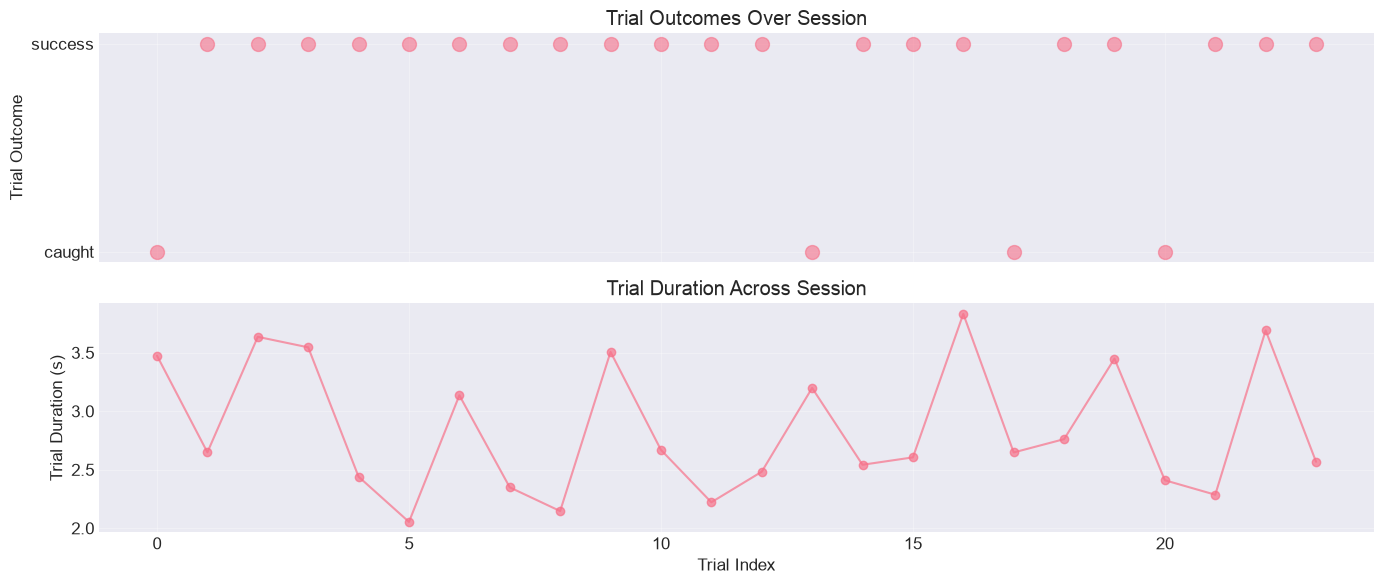

   → performance summary


  💾 Saved: analysis_results/performance_summary.png


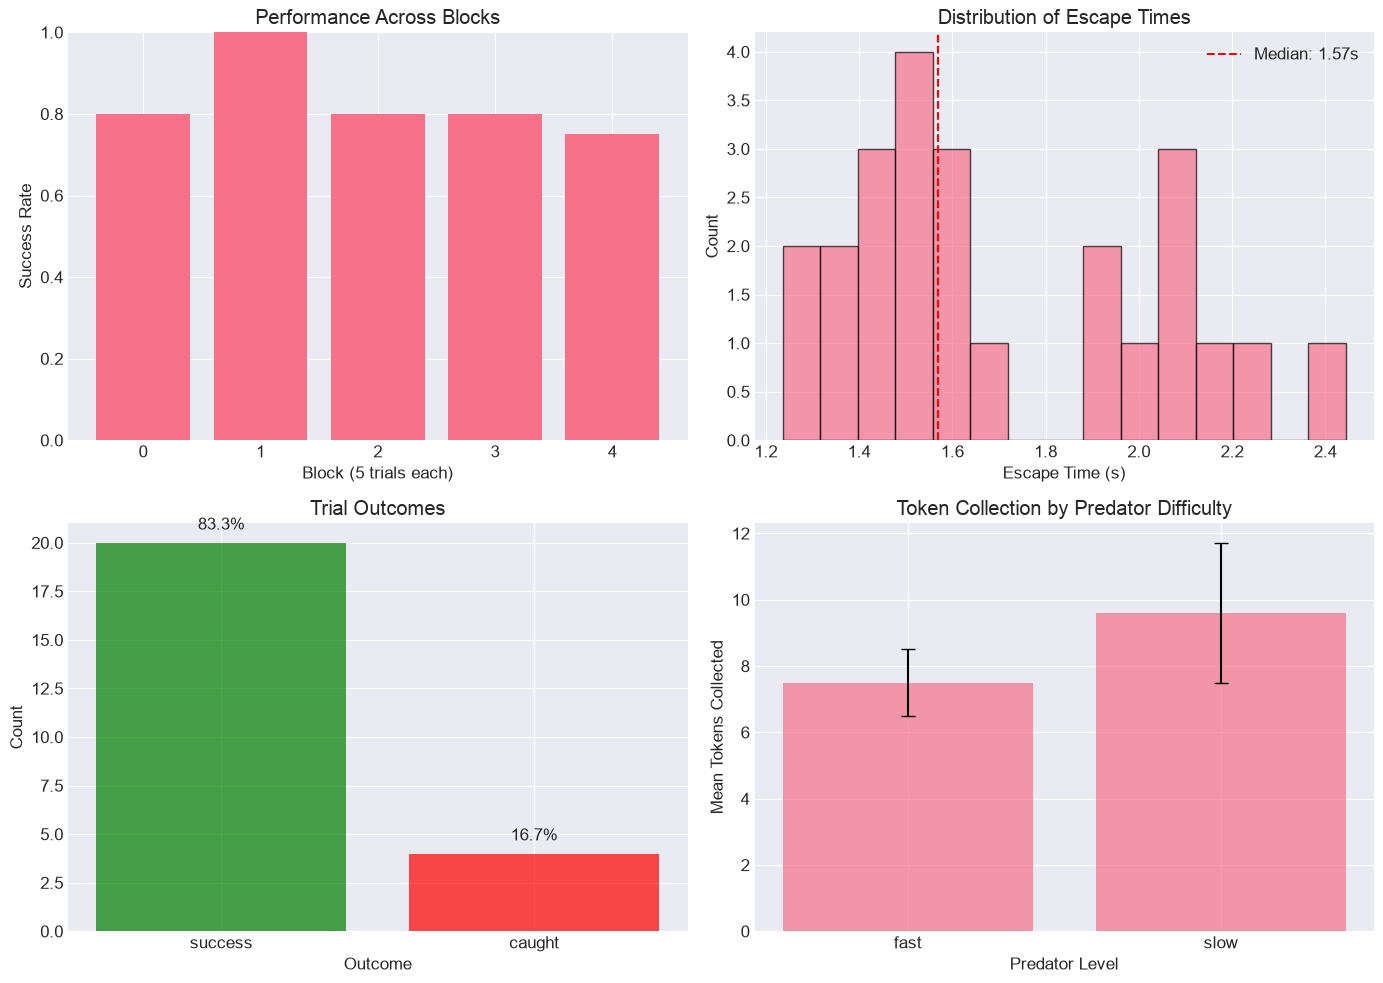

   → escape behavior


  💾 Saved: analysis_results/escape_behavior.png


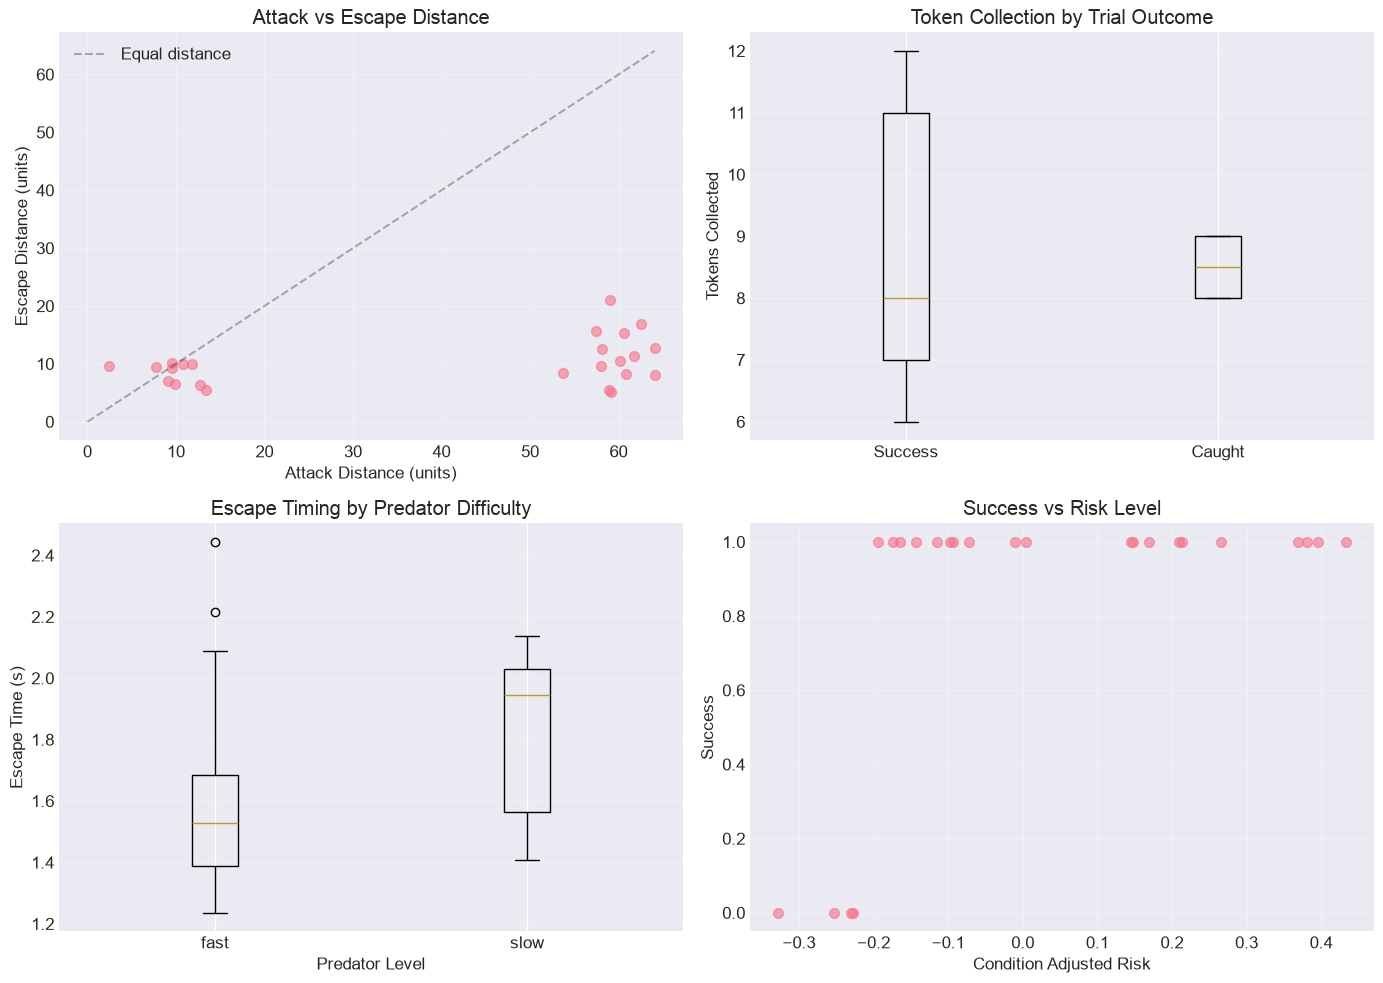


📊 frames
   → distance over time (first 5 trials)


  💾 Saved: analysis_results/frames_distance_over_time.png


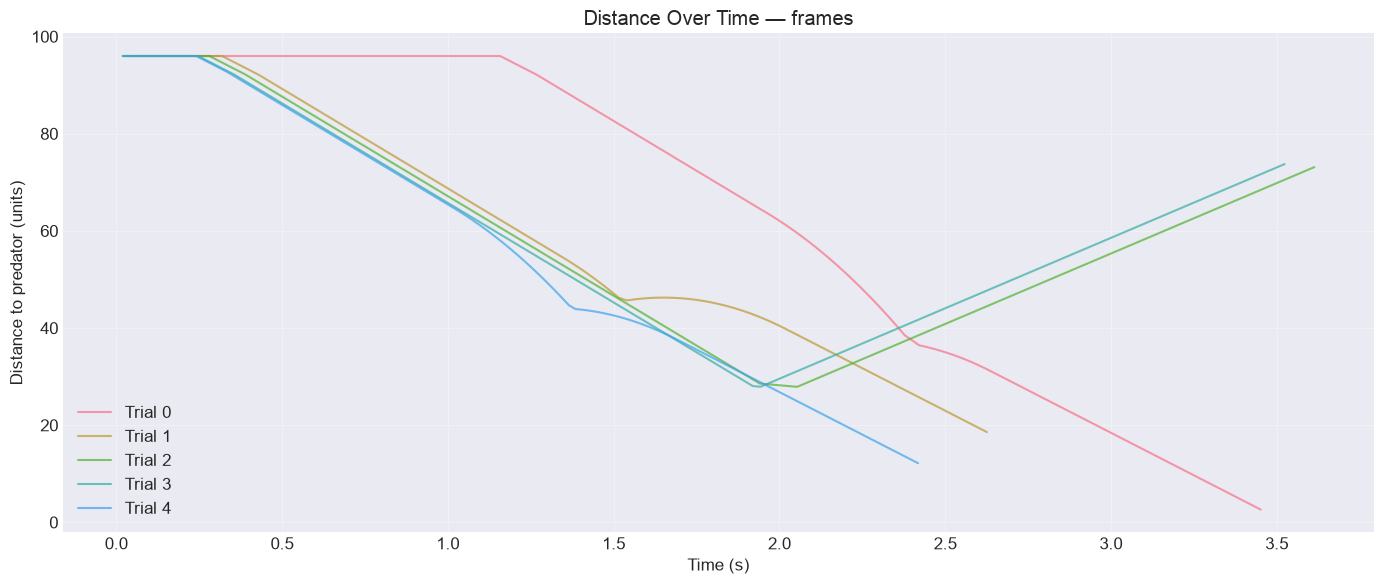

   → predator vs token distance


  💾 Saved: analysis_results/frames_predator_vs_token.png


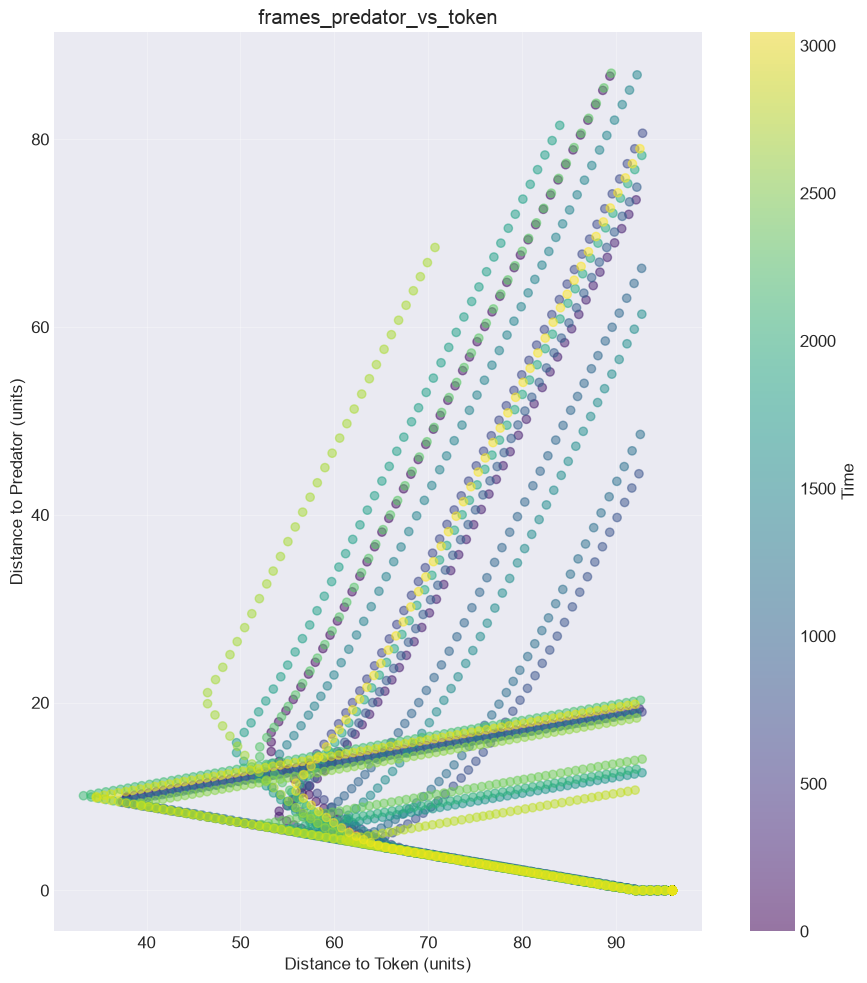

In [6]:
if data and data['files']:
    print(f"\n{'='*60}")
    print("GENERATING PLOTS")
    print(f"{'='*60}")

    trials_df = data['files'].get('trials')
    frames_df = data['files'].get('frames')

    # --- trials: per-trial summary plots ---
    if isinstance(trials_df, pd.DataFrame) and not trials_df.empty:
        print("\n📊 trials")
        print("   → trial timeline")
        plot_trial_timeline(trials_df)
        print("   → performance summary")
        plot_performance_summary(trials_df)
        if {'escape_on_elapsed_s', 'attack_distance_units'} & set(trials_df.columns):
            print("   → escape behavior")
            plot_escape_behavior(trials_df)

    # --- frames: per-frame time series and trajectory ---
    if isinstance(frames_df, pd.DataFrame) and not frames_df.empty:
        print("\n📊 frames")
        if 'elapsed_s' in frames_df.columns and 'distance_units' in frames_df.columns:
            print("   → distance over time (first 5 trials)")
            fig, ax = plt.subplots(figsize=(14, 6))
            for trial in sorted(frames_df['trial_index'].unique())[:5]:
                td = frames_df[frames_df['trial_index'] == trial]
                ax.plot(td['elapsed_s'], td['distance_units'], alpha=0.7, label=f'Trial {trial}')
            ax.legend()
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Distance to predator (units)')
            ax.set_title('Distance Over Time — frames')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            fname = FIGURES_DIR / 'frames_distance_over_time.png'
            fig.savefig(fname, dpi=150, bbox_inches='tight')
            print(f"  💾 Saved: {fname}")
            plt.show()

        if 'predator_units' in frames_df.columns and 'token_units' in frames_df.columns:
            print("   → predator vs token distance")
            plot_trajectory_data(frames_df, title="frames_predator_vs_token")

else:
    print("❌ No data loaded.")

## 4a. Predator Comparison & Kalman Optimal Escape Analysis

Three analyses run on `trials_df`:

1. **Predator comparison** — FID, success rate, and reward (tokens) split by fast vs slow predator. FID panel annotated with empirical mean ± SD.
2. **Kalman FID filter** — observed FID per trial smoothed with a 1-D Kalman filter (models the subject's latent intended escape distance), overlaid with the *analytical minimum safe FID* (the lowest FID at which the token can just outrun the predator to the safe zone given task physics).
3. **Kalman belief of attack distance** — models a Bayesian observer updating their estimate of the predator's mean attack distance trial-by-trial from attack-onset observations, and compares that learned belief to the subject's actual FID choices.

In [ ]:
# ─────────────────────────────────────────────────────────────
# Task physics — must match escape_task.py Config defaults
# ─────────────────────────────────────────────────────────────
_V_TOKEN   = 35.0   # token speed (units/s)
_V_PRE     = 6.0    # predator pre-attack speed (units/s)
_A_PRED    = 70.0   # attack acceleration (units/s²)
_V_MAX     = 70.0   # predator max speed (units/s)
_SAFE_X    = 92.0   # left border of safe zone (100 − 8 units)
_COLL_R    = 3.0    # collision radius (units)


# ─────────────────────────────────────────────────────────────
# Helper: analytical minimum safe FID
# ─────────────────────────────────────────────────────────────
def compute_min_safe_fid(token_x,
                         v_token=_V_TOKEN, v0_pred=_V_PRE,
                         a_pred=_A_PRED, v_max_pred=_V_MAX,
                         safe_x=_SAFE_X, collision_r=_COLL_R):
    """
    Analytical lower bound on FID: the minimum gap (token − predator) at which
    the token must start fleeing so a predator that begins a full attack at that
    instant just fails to catch it before it reaches the safe zone.

    Derivation:
      τ_safe  = time for token to reach safe_x at v_token
      Phase 1 (0 → τ₁): predator accelerates from v0 at a_pred to v_max
      Phase 2 (τ₁ → τ_safe): predator coasts at v_max
      Escape condition: predator_pos(τ_safe) < safe_x − collision_r
      → min_FID = pred_displacement(τ_safe) − (safe_x − token_x) + collision_r
    """
    if token_x >= safe_x:
        return 0.0
    tau_safe = (safe_x - token_x) / v_token
    tau1 = (v_max_pred - v0_pred) / a_pred        # time to reach max speed (≈ 0.914 s)
    disp1 = v0_pred * tau1 + 0.5 * a_pred * tau1 ** 2
    if tau_safe <= tau1:
        pred_disp = v0_pred * tau_safe + 0.5 * a_pred * tau_safe ** 2
    else:
        pred_disp = disp1 + v_max_pred * (tau_safe - tau1)
    return max(0.0, pred_disp - (safe_x - token_x) + collision_r)


# ─────────────────────────────────────────────────────────────
# Helper: 1-D Kalman filter on observed FID
# ─────────────────────────────────────────────────────────────
def kalman_filter_fid(fid_series, process_noise=4.0, obs_noise=6.0):
    """
    Models the subject's latent intended escape distance as a random-walk state.
    Each trial's observed FID is a noisy measurement of that latent state.

    process_noise: how much the intended FID can shift between trials (units)
    obs_noise:     motor/attentional noise around the intended FID (units)

    Returns (mu, sigma) arrays — filtered posterior mean and std at every trial.
    """
    fid  = np.asarray(fid_series, dtype=float)
    n    = len(fid)
    mu   = np.full(n, np.nan)
    sig  = np.full(n, np.nan)
    valid = ~np.isnan(fid)
    if not valid.any():
        return mu, sig
    Q, R = process_noise ** 2, obs_noise ** 2
    first = int(np.where(valid)[0][0])
    mu[first], sig[first] = fid[first], R
    for k in range(first + 1, n):
        mu_p  = mu[k - 1]
        sig_p = sig[k - 1] + Q
        if valid[k]:
            K     = sig_p / (sig_p + R)
            mu[k]  = mu_p + K * (fid[k] - mu_p)
            sig[k] = (1 - K) * sig_p
        else:
            mu[k], sig[k] = mu_p, sig_p
    return mu, sig


# ─────────────────────────────────────────────────────────────
# Helper: Kalman belief over predator's mean attack distance
# ─────────────────────────────────────────────────────────────
def kalman_belief_attack(attack_obs, prior_mean=50.0, prior_var=400.0, obs_noise=5.0):
    """
    Bayesian (Kalman) observer learning the predator's mean attack distance.

    attack_obs: array of attack_distance_units; NaN on trials with no observed attack.
    prior_mean: initial belief (50 = agnostic over [30,70] range)
    prior_var:  initial uncertainty variance (400 → σ ≈ 20 units)
    obs_noise:  SD of the attack-distance distribution (≈ task SD of 5 units)

    Returns (belief_mean, belief_sd) aligned with each trial.
    """
    obs = np.asarray(attack_obs, dtype=float)
    n   = len(obs)
    mu  = np.zeros(n)
    sd  = np.zeros(n)
    m, v = prior_mean, prior_var
    R = obs_noise ** 2
    for k in range(n):
        # No process noise: predator type's mean attack distance is fixed
        if not np.isnan(obs[k]):
            K = v / (v + R)
            m = m + K * (obs[k] - m)
            v = (1 - K) * v
        mu[k], sd[k] = m, np.sqrt(v)
    return mu, sd


# ─────────────────────────────────────────────────────────────
# Plot 1 — Predator comparison (FID, success, tokens)
# ─────────────────────────────────────────────────────────────
def plot_predator_comparison(trials_df):
    fast = trials_df[trials_df['predator'] == 'fast'].copy()
    slow = trials_df[trials_df['predator'] == 'slow'].copy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    rng = np.random.default_rng(0)

    # ── FID ──────────────────────────────────────────────────
    ax = axes[0]
    fid_f = fast['flight_initiation_distance_units'].dropna().values
    fid_s = slow['flight_initiation_distance_units'].dropna().values

    bp = ax.boxplot([fid_f, fid_s], positions=[1, 2], widths=0.45,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    bp['boxes'][0].set(facecolor='#ff9999', alpha=0.7)
    bp['boxes'][1].set(facecolor='#99ccff', alpha=0.7)

    # Jittered strip overlay
    ax.scatter(rng.uniform(0.82, 1.18, len(fid_f)), fid_f,
               s=60, color='crimson', alpha=0.85, zorder=5, edgecolors='white', linewidths=0.4)
    ax.scatter(rng.uniform(1.82, 2.18, len(fid_s)), fid_s,
               s=60, color='steelblue', alpha=0.85, zorder=5, edgecolors='white', linewidths=0.4)

    # Empirical mean ± SD annotations
    y_top = max(np.nanmax(fid_f) if len(fid_f) else 0,
                np.nanmax(fid_s) if len(fid_s) else 0)
    for pos, vals, col in [(1, fid_f, 'darkred'), (2, fid_s, 'navy')]:
        if len(vals):
            m, s = vals.mean(), vals.std()
            ax.annotate(f'μ = {m:.1f}\nσ = {s:.1f}',
                        xy=(pos, m), xytext=(pos + 0.28, m),
                        fontsize=10, color=col, va='center',
                        arrowprops=dict(arrowstyle='-', color=col, lw=1.0))

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Fast', 'Slow'], fontsize=12)
    ax.set_ylabel('Flight Initiation Distance (units)', fontsize=11)
    ax.set_title('Escape Distance (FID)', fontsize=12)
    ax.grid(True, alpha=0.25, axis='y')

    # ── Success rate ─────────────────────────────────────────
    ax = axes[1]
    sr_f = fast['success'].mean() if len(fast) else 0.0
    sr_s = slow['success'].mean() if len(slow) else 0.0
    bars = ax.bar(['Fast', 'Slow'], [sr_f, sr_s],
                  color=['#ff9999', '#99ccff'], alpha=0.85,
                  edgecolor='black', linewidth=1.2, width=0.5)
    for bar, rate, n in [(bars[0], sr_f, len(fast)), (bars[1], sr_s, len(slow))]:
        ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.03,
                f'{rate * 100:.1f}%\n(n = {n})', ha='center', fontsize=11)
    ax.set_ylim(0, 1.3)
    ax.set_ylabel('Success Rate', fontsize=11)
    ax.set_title('Success Rate', fontsize=12)
    ax.grid(True, alpha=0.25, axis='y')

    # ── Tokens (reward) ──────────────────────────────────────
    ax = axes[2]
    means = [fast['tokens'].mean(), slow['tokens'].mean()]
    sds   = [fast['tokens'].std(),  slow['tokens'].std()]
    ax.bar(['Fast', 'Slow'], means, yerr=sds,
           color=['#ff9999', '#99ccff'], alpha=0.85,
           edgecolor='black', linewidth=1.2, capsize=8, width=0.5)
    # Overlay individual points
    ax.scatter(rng.uniform(-0.18, 0.18, len(fast)), fast['tokens'],
               s=40, color='crimson', alpha=0.6, zorder=5)
    ax.scatter(1 + rng.uniform(-0.18, 0.18, len(slow)), slow['tokens'],
               s=40, color='steelblue', alpha=0.6, zorder=5)
    for i, (m, s) in enumerate(zip(means, sds)):
        ax.text(i, m + s + 0.2, f'{m:.1f} ± {s:.1f}', ha='center', fontsize=10)
    ax.set_ylabel('Tokens Collected', fontsize=11)
    ax.set_title('Reward (Tokens)', fontsize=12)
    ax.grid(True, alpha=0.25, axis='y')

    fig.suptitle('Fast vs Slow Predator — Behavioral Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'predator_comparison.png', dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / 'predator_comparison.png'}")
    plt.show()


# ─────────────────────────────────────────────────────────────
# Plot 2 — Kalman FID vs analytical minimum safe FID
# ─────────────────────────────────────────────────────────────
def plot_kalman_fid(trials_df):
    """
    Per predator type, in chronological trial order:
      • Scatter of observed FID (green = success, red = caught)
      • Kalman-filtered latent FID estimate ± 1 σ
      • Per-trial analytical minimum safe FID (gold tick marks)
      • Empirical mean attack distance as a dashed reference
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    pred_styles = {'fast': ('crimson', 'Fast'), 'slow': ('steelblue', 'Slow')}

    for ax, pred_type in zip(axes, ['fast', 'slow']):
        color, label = pred_styles[pred_type]
        sub = (trials_df[trials_df['predator'] == pred_type]
               .sort_values('trial_index').reset_index(drop=True))
        if sub.empty:
            ax.set_title(f'{label} — no trials'); continue

        fid      = sub['flight_initiation_distance_units'].values
        tok_x    = sub['escape_token_units'].values
        outcomes = sub['outcome'].values
        trial_x  = np.arange(len(sub))

        # Analytical per-trial minimum safe FID
        opt = np.array([compute_min_safe_fid(tx) if not np.isnan(tx) else np.nan
                        for tx in tok_x])

        # Kalman filter on observed FID
        mu_k, sig_k = kalman_filter_fid(fid)

        # Scatter observed FID coloured by outcome
        c_pts = ['#27ae60' if o == 'success' else '#c0392b' for o in outcomes]
        ax.scatter(trial_x, fid, c=c_pts, s=90, zorder=5,
                   edgecolors='black', linewidths=0.5, label='Observed FID')

        # Kalman estimate + uncertainty band
        valid = ~np.isnan(mu_k)
        ax.plot(trial_x[valid], mu_k[valid], color=color, lw=2.5,
                zorder=4, label='Kalman estimate')
        ax.fill_between(trial_x[valid],
                        mu_k[valid] - np.sqrt(sig_k[valid]),
                        mu_k[valid] + np.sqrt(sig_k[valid]),
                        alpha=0.18, color=color)

        # Min-safe FID ticks
        valid_opt = ~np.isnan(opt)
        ax.scatter(trial_x[valid_opt], opt[valid_opt],
                   marker='_', s=220, color='gold',
                   linewidths=2.5, zorder=3, label='Min safe FID')

        # Empirical mean attack distance reference
        emp_attack_mean = sub['attack_distance_units'].mean()
        emp_attack_sd   = sub['attack_distance_units'].std()
        ax.axhline(emp_attack_mean, color=color, linestyle=':', alpha=0.55, lw=1.8,
                   label=f'Mean attack dist. ({emp_attack_mean:.1f} ± {emp_attack_sd:.1f} u)')
        ax.axhspan(emp_attack_mean - emp_attack_sd, emp_attack_mean + emp_attack_sd,
                   alpha=0.07, color=color)

        ax.set_xlabel('Trial # (within this predator type)', fontsize=11)
        ax.set_ylabel('FID (units)', fontsize=11)
        ax.set_title(f'{label} Predator  (n = {len(sub)})', fontsize=12)
        ax.legend(fontsize=8.5, loc='upper left')
        ax.grid(True, alpha=0.25)

    # Shared outcome legend
    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(facecolor='#27ae60', ec='black', label='Success'),
                        Patch(facecolor='#c0392b', ec='black', label='Caught')],
               loc='upper right', fontsize=10, title='Outcome')
    fig.suptitle('Kalman-Smoothed FID vs Analytical Minimum Safe FID',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'kalman_fid.png', dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / 'kalman_fid.png'}")
    plt.show()


# ─────────────────────────────────────────────────────────────
# Plot 3 — Kalman belief of attack distance vs subject FID
# ─────────────────────────────────────────────────────────────
def plot_kalman_belief(trials_df):
    """
    A Bayesian observer updates their belief about the predator's mean attack
    distance from each trial on which an attack was actually observed.
    Compares the converging belief to the subject's actual FID choices.

    Trials with no attack onset (attack_on_elapsed_s = NaN) leave the belief
    unchanged — subject fled before the predator triggered its attack.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
    pred_info = [('fast', 'crimson', axes[0]), ('slow', 'steelblue', axes[1])]

    for pred_type, color, ax in pred_info:
        sub = (trials_df[trials_df['predator'] == pred_type]
               .sort_values('trial_index').reset_index(drop=True))
        if sub.empty:
            ax.set_title(f'{pred_type.capitalize()} — no trials'); continue

        # Observed attack distance only on trials where an attack occurred
        attack_obs = sub['attack_distance_units'].where(
            sub['attack_on_elapsed_s'].notna(), np.nan
        ).values

        n_observed = int(np.sum(~np.isnan(attack_obs)))
        emp_mean   = sub['attack_distance_units'].mean()

        belief_mu, belief_sd = kalman_belief_attack(
            attack_obs, prior_mean=50.0, prior_var=400.0, obs_noise=5.0
        )

        trial_x = np.arange(len(sub))

        # True (empirical) mean attack distance
        ax.axhline(emp_mean, color=color, linestyle='--', alpha=0.5, lw=1.8,
                   label=f'Empirical mean attack dist. ({emp_mean:.1f} u)')

        # Kalman belief ± 1 SD
        ax.plot(trial_x, belief_mu, color=color, lw=2.5,
                label=f'Kalman belief ({n_observed} attack obs.)')
        ax.fill_between(trial_x, belief_mu - belief_sd, belief_mu + belief_sd,
                        alpha=0.20, color=color, label='±1 SD belief')

        # Observed attack distance markers
        valid = ~np.isnan(attack_obs)
        if valid.any():
            ax.scatter(trial_x[valid], attack_obs[valid],
                       color='black', s=80, zorder=5, marker='x',
                       linewidths=2.2, label='Observed attack dist.')

        # Subject FID (triangles)
        success_mask = sub['outcome'] == 'success'
        ax.scatter(trial_x[success_mask],
                   sub.loc[success_mask, 'flight_initiation_distance_units'],
                   marker='^', color='#27ae60', edgecolors='black',
                   s=90, zorder=5, alpha=0.9, label='Subject FID (success)')
        caught_mask = sub['outcome'] == 'caught'
        if caught_mask.any():
            ax.scatter(trial_x[caught_mask],
                       sub.loc[caught_mask, 'flight_initiation_distance_units'],
                       marker='^', color='#c0392b', edgecolors='black',
                       s=90, zorder=5, alpha=0.9, label='Subject FID (caught)')

        ax.set_xlabel('Trial # (within this predator type)', fontsize=11)
        ax.set_ylabel('Distance (units)', fontsize=11)
        ax.set_title(f'{pred_type.capitalize()} Predator — Kalman Belief vs Subject FID  (n = {len(sub)})',
                     fontsize=12)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.25)

    fig.suptitle('Bayesian (Kalman) Learning of Attack Distance\nvs Subject Flight Initiation Distance',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'kalman_belief.png', dpi=150, bbox_inches='tight')
    print(f"  💾 Saved: {FIGURES_DIR / 'kalman_belief.png'}")
    plt.show()


# ─────────────────────────────────────────────────────────────
# Run all three analyses
# ─────────────────────────────────────────────────────────────
if data and isinstance(data['files'].get('trials'), pd.DataFrame):
    _t = data['files']['trials']
    print("── Predator comparison ──────────────────────────────────")
    plot_predator_comparison(_t)
    print("\n── Kalman FID vs min-safe FID ───────────────────────────")
    plot_kalman_fid(_t)
    print("\n── Kalman belief of attack distance ─────────────────────")
    plot_kalman_belief(_t)
else:
    print("❌  trials DataFrame not found — run the data-loading cell first.")

In [7]:
def diagnose_plotting_issues(data):
    """
    Diagnose why plots might not be generating
    """
    print("="*60)
    print("DIAGNOSTIC REPORT")
    print("="*60)
    
    if not data:
        print("\n❌ ISSUE: No data object found")
        print("Solution: Make sure to run the data loading cell first")
        return
    
    if not data.get('files'):
        print("\n❌ ISSUE: Data object exists but no files loaded")
        print("Solution: Check that your data folder contains supported file types")
        return
    
    print(f"\n✓ Data loaded successfully")
    print(f"  - Files found: {len(data['files'])}")
    
    # Check each file
    for key, value in data['files'].items():
        print(f"\n📁 File: {key}")
        
        if isinstance(value, pd.DataFrame):
            print(f"  Type: pandas DataFrame")
            print(f"  Shape: {value.shape}")
            
            # Check for empty dataframe
            if value.empty:
                print("  ⚠️ DataFrame is empty")
                continue
                
            # Check columns
            print(f"  Columns ({len(value.columns)}): {list(value.columns)[:10]}")
            
            # Suggest appropriate plots
            print("\n  📊 Suggested plots for this data:")
            
            # Check for trial data
            trial_indicators = ['trial', 'Trial', 'trial_number', 'trial_id', 'trial_num']
            if any(col in value.columns for col in trial_indicators):
                print("    ✓ Trial timeline plots (trial data detected)")
            
            # Check for position data
            if ('x' in value.columns and 'y' in value.columns) or \
               ('X' in value.columns and 'Y' in value.columns):
                print("    ✓ Trajectory plots (position data detected)")
            
            # Check for time series
            numeric_cols = value.select_dtypes(include=[np.number]).columns
            if len(numeric_cols) > 0:
                print(f"    ✓ Time series plots ({len(numeric_cols)} numeric columns)")
            
            # Check for categorical data
            cat_cols = value.select_dtypes(include=['object', 'category']).columns
            if len(cat_cols) > 0:
                print(f"    ✓ Category plots ({len(cat_cols)} categorical columns)")
                
        elif isinstance(value, np.ndarray):
            print(f"  Type: NumPy array")
            print(f"  Shape: {value.shape}")
            print(f"  Dtype: {value.dtype}")
            
            if len(value.shape) == 2:
                if value.shape[1] == 2:
                    print("    ✓ Can plot as 2D trajectory")
                else:
                    print(f"    ✓ Can plot as multi-channel time series ({value.shape[1]} channels)")
            elif len(value.shape) == 1:
                print("    ✓ Can plot as 1D time series")
                
        elif isinstance(value, dict):
            print(f"  Type: Dictionary with {len(value)} keys")
            print(f"  Keys: {list(value.keys())[:10]}")
            
    # Check matplotlib backend
    import matplotlib
    print(f"\n📈 Matplotlib backend: {matplotlib.get_backend()}")
    if 'inline' not in matplotlib.get_backend().lower():
        print("  ⚠️ Backend might not display plots in notebook")
        print("  Solution: Add '%matplotlib inline' to the imports cell")

# Run diagnostic
diagnose_plotting_issues(data)

DIAGNOSTIC REPORT

✓ Data loaded successfully
  - Files found: 4

📁 File: summary

📁 File: frames
  Type: pandas DataFrame
  Shape: (3046, 11)
  Columns (11): ['attack_distance_units', 'attack_started', 'distance_units', 'elapsed_s', 'in_safe_zone', 'outcome', 'predator', 'predator_units', 'token_units', 'tokens']

  📊 Suggested plots for this data:
    ✓ Time series plots (7 numeric columns)
    ✓ Category plots (2 categorical columns)

📁 File: trials
  Type: pandas DataFrame
  Shape: (24, 20)
  Columns (20): ['attack_distance_units', 'attack_on_elapsed_s', 'attack_on_predator_units', 'attack_on_token_units', 'collected_dot_indices', 'condition_adjusted_risk', 'escape_on_elapsed_s', 'escape_predator_units', 'escape_token_units', 'final_predator_units']

  📊 Suggested plots for this data:
    ✓ Time series plots (16 numeric columns)
    ✓ Category plots (3 categorical columns)

📁 File: trials_tsv
  Type: pandas DataFrame
  Shape: (24, 17)
  Columns (17): ['trial_index', 'predator', 'su

## 5. Custom Analysis

Space for custom analyses based on your specific data:

In [8]:
# Custom analysis code here
# Access loaded data using: data['files']['filename_without_extension']

if data:
    print("\nAvailable data files for analysis:")
    for key in data['files'].keys():
        print(f"  - data['files']['{key}']")
    
    # Example: Access specific file
    # df = data['files']['trials']  # Replace 'trials' with actual filename
    # your_analysis_here(df)


Available data files for analysis:
  - data['files']['summary']
  - data['files']['frames']
  - data['files']['trials']
  - data['files']['trials_tsv']


## 6. Statistical Summary

Generate statistical summaries of the data:

In [9]:
def generate_statistics_report(data):
    """
    Generate a statistical summary of all numeric data.
    """
    if not data or not data['files']:
        print("No data available for statistical analysis")
        return

    print("\n" + "="*60)
    print("STATISTICAL SUMMARY")
    print("="*60)

    for key, value in data['files'].items():
        if isinstance(value, pd.DataFrame):
            print(f"\n📊 {key} (DataFrame)")
            print("-" * 40)
            print(value.describe())

            cat_cols = value.select_dtypes(include=['object', 'category']).columns
            if len(cat_cols) > 0:
                print("\nCategorical Variables:")
                for col in cat_cols:
                    try:
                        n_unique = value[col].nunique()
                        print(f"  {col}: {n_unique} unique values")
                        if n_unique < 10:
                            print(f"    Values: {value[col].value_counts().to_dict()}")
                    except TypeError:
                        print(f"  {col}: contains non-scalar values (e.g. lists), skipped")

        elif isinstance(value, np.ndarray):
            print(f"\n📊 {key} (NumPy Array)")
            print("-" * 40)
            print(f"  Shape: {value.shape}")
            print(f"  Mean: {np.mean(value):.4f}")
            print(f"  Std: {np.std(value):.4f}")
            print(f"  Min: {np.min(value):.4f}")
            print(f"  Max: {np.max(value):.4f}")
            print(f"  Median: {np.median(value):.4f}")

# Generate statistics
generate_statistics_report(data)


STATISTICAL SUMMARY

📊 frames (DataFrame)
----------------------------------------
       attack_distance_units  distance_units    elapsed_s  predator_units  \
count            3046.000000     3046.000000  3046.000000     3046.000000   
mean               36.383489       61.911392     1.468115       12.620546   
std                25.289741       24.285680     0.906916       17.679944   
min                 2.490648        2.239961     0.017278        0.000000   
25%                 9.529089       43.734526     0.704640        1.354704   
50%                53.709307       61.973234     1.417028        6.045756   
75%                60.160467       82.941720     2.130145       14.715434   
max                64.073802       96.000000     3.810521       87.039881   

       token_units       tokens  trial_index  
count  3046.000000  3046.000000  3046.000000  
mean     74.531938     5.577807    11.417269  
std      15.786403     3.761400     7.059230  
min      33.284372     0.000000   

## 7. Export Results

Save analysis results and figures:

In [10]:
# Create output directory for results
output_dir = Path('analysis_results')
output_dir.mkdir(exist_ok=True)

def save_analysis_results(data, output_dir):
    """
    Save analysis results to files.
    """
    if not data:
        return
    
    # Save summary statistics
    summary = {}
    for key, value in data['files'].items():
        if isinstance(value, pd.DataFrame):
            summary[key] = {
                'shape': value.shape,
                'columns': list(value.columns),
                'dtypes': value.dtypes.to_dict()
            }
    
    # Save summary as JSON
    with open(output_dir / 'data_summary.json', 'w') as f:
        json.dump(summary, f, indent=2, default=str)
    
    print(f"\n✅ Analysis results saved to '{output_dir}'")
    print(f"   - data_summary.json")

# Save results
save_analysis_results(data, output_dir)

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print("\nNext steps:")
print("1. Review the generated plots and statistics")
print("2. Modify the custom analysis section for your specific needs")
print("3. Re-run with different data folders as needed")
print("4. Export figures using plt.savefig() before plt.show()")


✅ Analysis results saved to 'analysis_results'
   - data_summary.json

ANALYSIS COMPLETE

Next steps:
1. Review the generated plots and statistics
2. Modify the custom analysis section for your specific needs
3. Re-run with different data folders as needed
4. Export figures using plt.savefig() before plt.show()
